# 02 — Exploratory Data Analysis & Visualización

In [49]:
# Carga del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/VDP001_01_clean.csv')
df.head()

,COD_PROVINCIA,PROVINCIA,COD_POSTAL,NOMBRE_MUNICIPIO,ELEMENTO,TIPO_VIVIENDA,TIPO_MEDIDA,AÑO,VALOR
0,8,Barcelona,8209,Sant Fost de Campsentelles,SUPERFICIE,COLECTIVA,PERCENT25,2012,68
1,8,Barcelona,8114,Martorell,SUPERFICIE,COLECTIVA,PERCENT25,2012,68
2,8,Barcelona,8115,Martorelles,SUPERFICIE,COLECTIVA,PERCENT25,2012,68
3,8,Barcelona,8307,Vilanova i la Geltrú,SUPERFICIE,COLECTIVA,PERCENT25,2012,68
4,8,Barcelona,8145,Olèrdola,SUPERFICIE,COLECTIVA,PERCENT25,2012,68


In [50]:
# Valores únicos de las columnas más importantes
print("Años:", df['AÑO'].unique())
print("Elemento:", df['ELEMENTO'].unique())
print("Tipo vivienda:", df['TIPO_VIVIENDA'].unique())
print("Tipo medida:", df['TIPO_MEDIDA'].unique())
print("Provincias:", df['PROVINCIA'].nunique())

Años: [2012 2011 2013 2015 2016 2024 2017 2019 2020 2018 2023 2021 2014 2022]
Elemento: ['SUPERFICIE' 'PRECIO' 'VIVIENDA']
Tipo vivienda: ['COLECTIVA' 'UNIFAMILIAR']
Tipo medida: ['PERCENT25' 'PERCENT75' 'MEDIANA' 'RECUENTO']
Provincias: 52


In [51]:
# Filtrado de datos: precio mediano por municipio
# Nos quedamos solo con las filas donde ELEMENTO es 'PRECIO' y TIPO_MEDIDA es 'MEDIANA'
# La mediana es más representativa que la media porque no se ve afectada por valores extremos
df_precio = df[(df['ELEMENTO'] == 'PRECIO') & (df['TIPO_MEDIDA'] == 'MEDIANA')]
df_precio.shape

(61775, 9)

In [52]:
# Estadísticas descriptivas del precio mediano
# Nos da una primera visión de la distribución: mínimo, máximo, media, desviación típica...
df_precio['VALOR'].describe()

count    61775.000000
mean       401.719984
std        154.761940
min         51.000000
25%        300.000000
50%        360.000000
75%        464.000000
max       2280.000000
Name: VALOR, dtype: float64

In [53]:
# Ver valores únicos de TIPO_MEDIDA y ELEMENTO para entender qué representa VALOR
print(df['TIPO_MEDIDA'].unique())
print(df['ELEMENTO'].unique())
print(df['VALOR'].unique()[:20])

['PERCENT25' 'PERCENT75' 'MEDIANA' 'RECUENTO']
['SUPERFICIE' 'PRECIO' 'VIVIENDA']
[68 66 70 73 65 64 72 71 67 69 63 62 61 60 59 77 74 76 78 75]


In [54]:
# NOTA: La columna VALOR representa índices de precio relativos del INE, NO precios en euros
# Esto nos permite comparar evolución temporal y diferencias entre zonas, pero no precios absolutos

## ANÁLISIS UNIVARIANTE

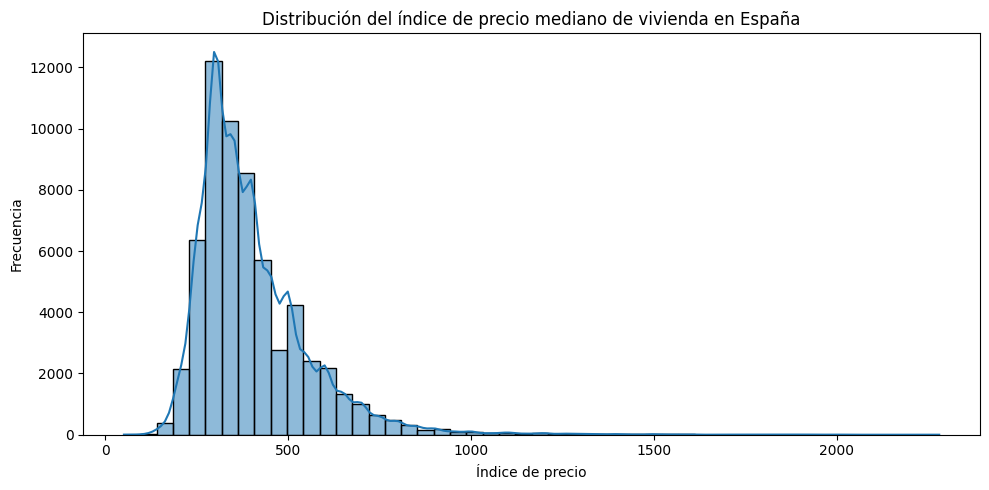

In [55]:
# Distribución general del precio mediano
# Nos da una primera visión de cómo se reparten los precios en España
plt.figure(figsize=(10, 5))
sns.histplot(df_precio['VALOR'], bins=50, kde=True)
plt.title('Distribución del índice de precio mediano de vivienda en España')
plt.xlabel('Índice de precio')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('../img/01_distribucion_precios.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusiones — Distribución general de precios

- La mayoría de municipios se concentran entre índice **250 y 500**
- La distribución tiene **cola larga a la derecha** — hay pocos municipios con índices muy altos (por encima de 1000), que corresponden a las grandes ciudades
- Es una distribución **asimétrica positiva**, lo que indica una gran desigualdad de precios entre municipios

## HIPÓTESIS 3 - El precio del alquiler ha aumentado progresivamente con el paso de los años

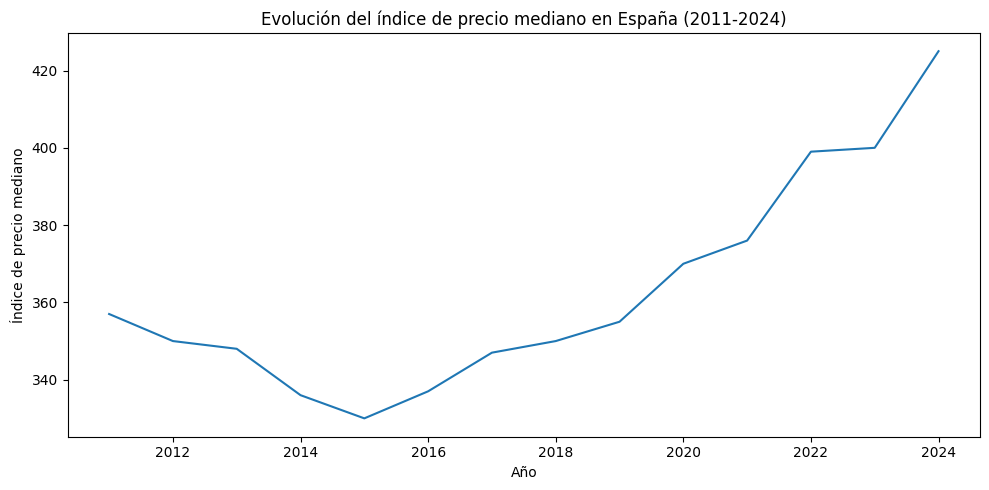

In [56]:
# H3 — ¿El precio ha aumentado progresivamente con los años?
evolucion = df_precio.groupby('AÑO')['VALOR'].median()

plt.figure(figsize=(10, 5))
sns.lineplot(x=evolucion.index, y=evolucion.values)
plt.title('Evolución del índice de precio mediano en España (2011-2024)')
plt.xlabel('Año')
plt.ylabel('Índice de precio mediano')
plt.tight_layout()
plt.savefig('../img/02_evolucion_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusiones — H3: Evolución temporal del precio

- **2011-2015**: caída de precios, coincide con la crisis inmobiliaria post-burbuja de 2008
- **2015-2019**: recuperación gradual del mercado
- **2019-2024**: subida acelerada, especialmente a partir de 2021

✅ **H3 confirmada** — el precio ha aumentado progresivamente, aunque con una caída previa asociada a la crisis económica

## HIPÓTESIS 1 - Las grandes provincias presentan precios de alquiler significativamente superiores

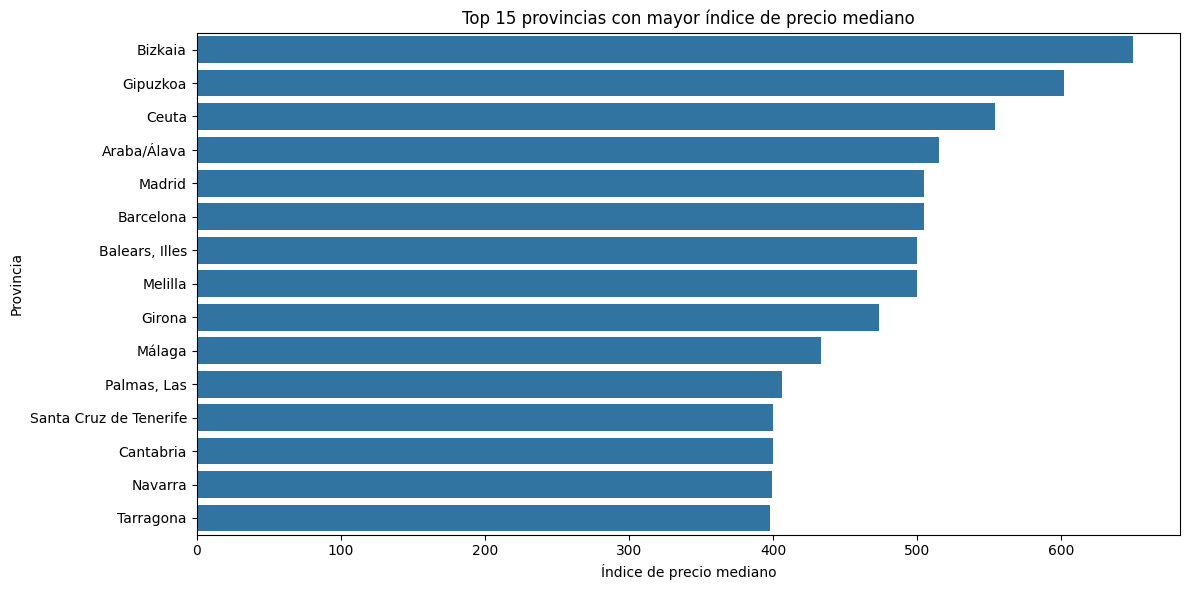

In [57]:
# H1 — ¿Las grandes provincias tienen precios más altos?
top_provincias = df_precio.groupby('PROVINCIA')['VALOR'].median().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_provincias.values, y=top_provincias.index)
plt.title('Top 15 provincias con mayor índice de precio mediano')
plt.xlabel('Índice de precio mediano')
plt.ylabel('Provincia')
plt.tight_layout()
plt.savefig('../img/03_ranking_provincias.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusiones — H1: Precios por provincia

- **Bizkaia y Gipuzkoa** lideran el ranking — el País Vasco domina por encima de Madrid y Barcelona
- **Madrid y Barcelona** aparecen en el top 15 pero no son las más caras, resultado inesperado
- **Ceuta y Melilla** también destacan a pesar de su tamaño reducido

⚠️ **H1 parcialmente confirmada** — las grandes provincias tienen precios altos, pero no son necesariamente las más caras

## HIPÓTESIS 2 - Existe una desigualdad territorial clara entre comunidades autónomas

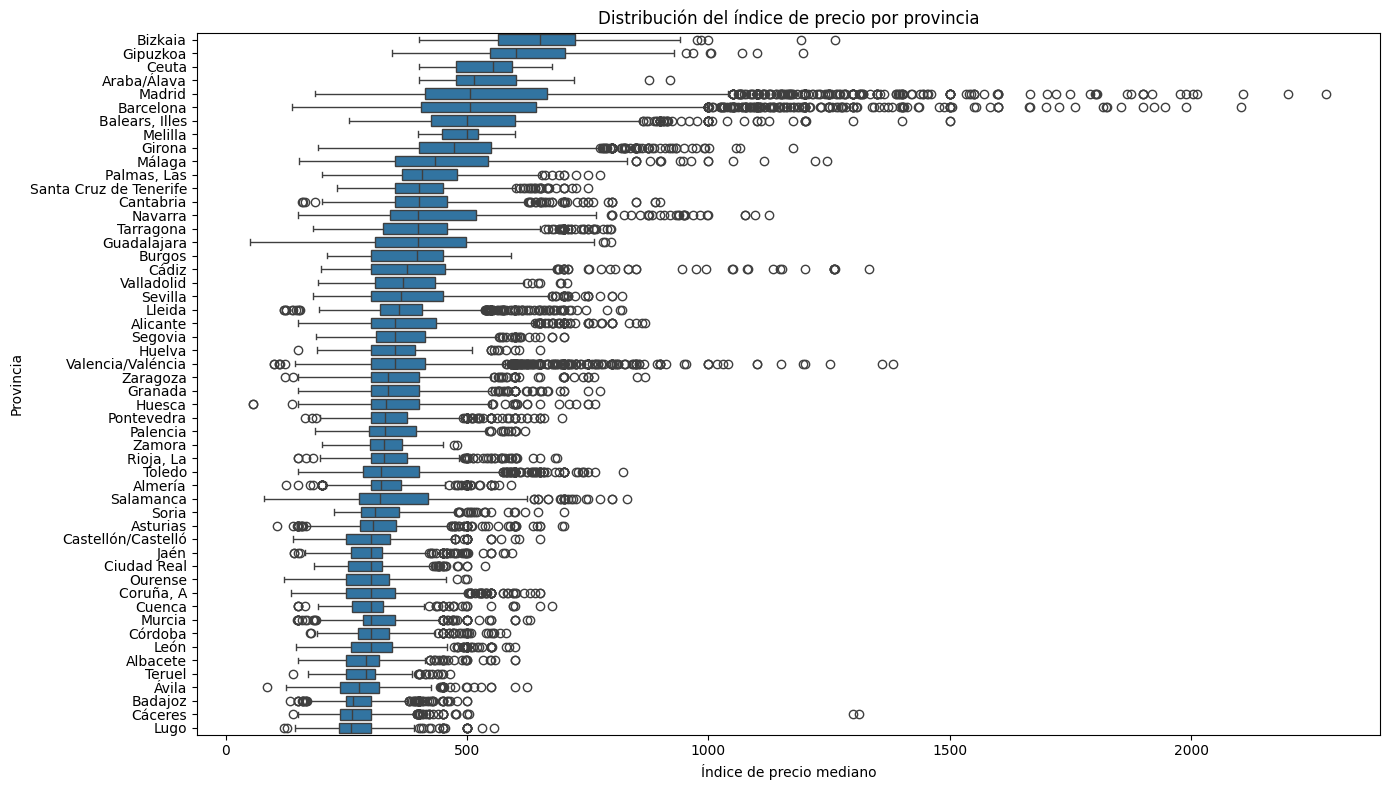

In [58]:
# H2 — ¿Existe desigualdad territorial clara entre provincias?
precio_provincia = df_precio.groupby('PROVINCIA')['VALOR'].median().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_precio, x='VALOR', y='PROVINCIA', 
            order=precio_provincia.index)
plt.title('Distribución del índice de precio por provincia')
plt.xlabel('Índice de precio mediano')
plt.ylabel('Provincia')
plt.tight_layout()
plt.savefig('../img/04_desigualdad_territorial.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusiones — H2: Desigualdad territorial entre provincias

- Existe una **desigualdad territorial clara** entre provincias
- **Bizkaia, Gipuzkoa y Madrid** muestran mayor dispersión — más variedad de precios dentro de la propia provincia
- **Barcelona y Madrid** tienen outliers muy extremos (hasta 2.000+) — municipios de lujo dentro de la provincia
- Las provincias del interior como **Lugo, Cáceres o Teruel** tienen índices bajos y muy concentrados — poca variabilidad

✅ **H2 confirmada** — existe una desigualdad territorial significativa entre provincias

## HIPÓTESIS 4 - El tipo de vivienda influye en el precio del alquiler

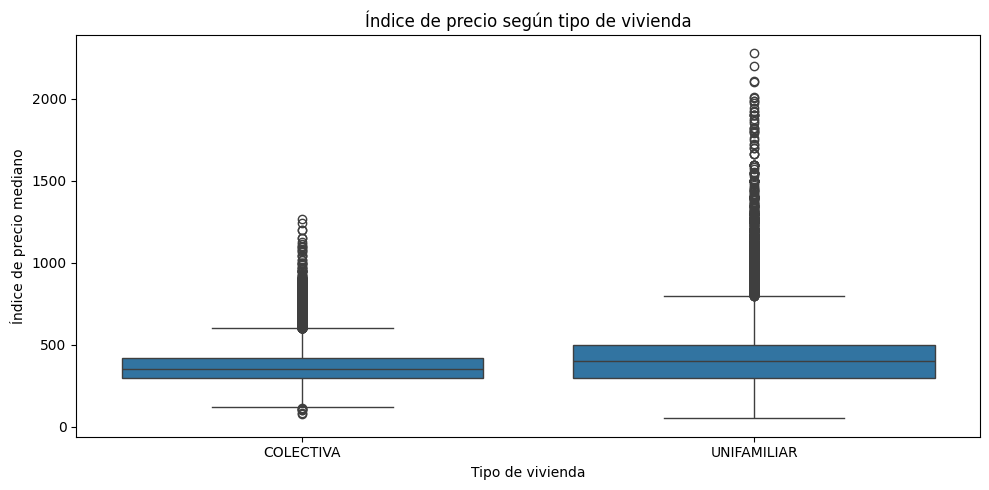

In [59]:
# H4 — ¿El tipo de vivienda influye en el precio?
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_precio, x='TIPO_VIVIENDA', y='VALOR')
plt.title('Índice de precio según tipo de vivienda')
plt.xlabel('Tipo de vivienda')
plt.ylabel('Índice de precio mediano')
plt.tight_layout()
plt.savefig('../img/05_tipo_vivienda.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusiones — H4: Tipo de vivienda y precio

- La **vivienda unifamiliar** tiene mayor dispersión y outliers más extremos (hasta 2.200+)
- La **vivienda colectiva** es más homogénea y concentrada en índices más bajos
- La mediana de ambos tipos es similar, pero la unifamiliar tiene mayor variabilidad

⚠️ **H4 parcialmente confirmada** — el tipo de vivienda influye más en la variabilidad del precio que en el precio mediano en sí

## ANÁLISIS MULTIVARIANTE

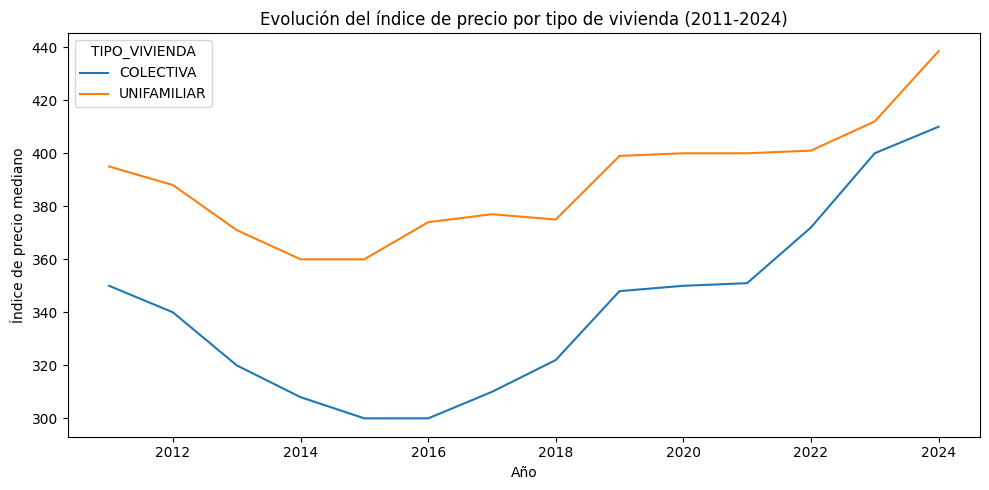

In [60]:
# Evolución del precio por año y tipo de vivienda
evolucion_tipo = df_precio.groupby(['AÑO', 'TIPO_VIVIENDA'])['VALOR'].median().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=evolucion_tipo, x='AÑO', y='VALOR', hue='TIPO_VIVIENDA')
plt.title('Evolución del índice de precio por tipo de vivienda (2011-2024)')
plt.xlabel('Año')
plt.ylabel('Índice de precio mediano')
plt.tight_layout()
plt.savefig('../img/06_evolucion_tipo_vivienda.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusiones — Multivariante: Evolución por tipo de vivienda

- La **unifamiliar** mantiene precios superiores a la colectiva en todo el período
- Ambos tipos siguen la misma tendencia: caída hasta 2015 y recuperación posterior
- A partir de 2021 **ambos se disparan**, pero la colectiva lo hace con más fuerza proporcionalmente, reduciendo la brecha entre ambos tipos

## HEATMAP — Correlación entre variables numéricas

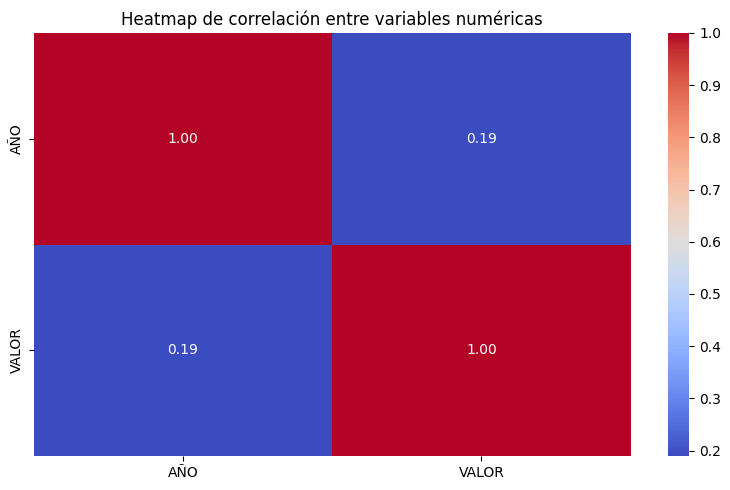

In [61]:
plt.figure(figsize=(8, 5))
sns.heatmap(df_precio[['AÑO', 'VALOR']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap de correlación entre variables numéricas')
plt.tight_layout()
plt.savefig('../img/07_heatmap_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusiones — Heatmap de correlación

- La correlación entre **AÑO y VALOR es 0.19** — relación positiva pero débil
- La baja correlación se explica porque los precios bajaron entre 2011-2015 antes de subir, lo que rompe la linealidad

## SCATTERPLOT — Relación entre año y precio mediano

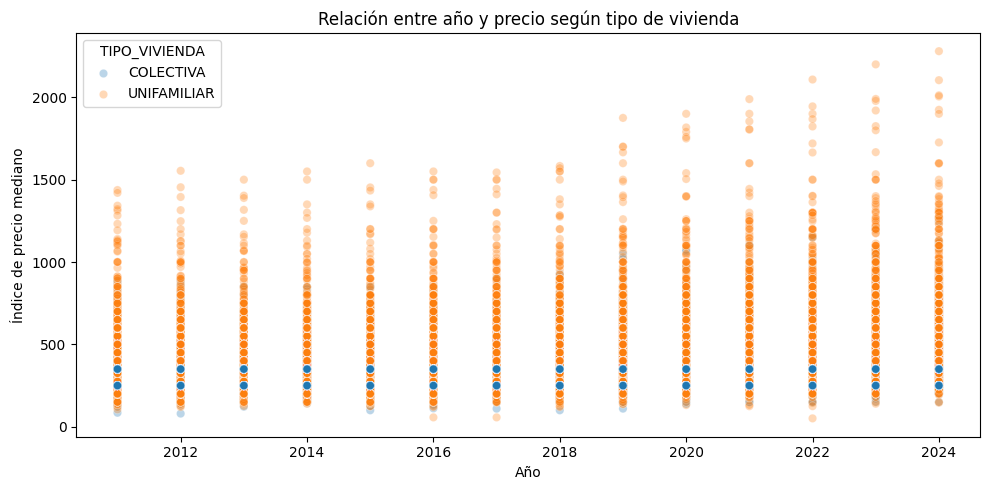

In [62]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_precio, x='AÑO', y='VALOR', hue='TIPO_VIVIENDA', alpha=0.3)
plt.title('Relación entre año y precio según tipo de vivienda')
plt.xlabel('Año')
plt.ylabel('Índice de precio mediano')
plt.tight_layout()
plt.savefig('../img/08_scatterplot_anyo_precio.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusiones — Scatterplot: Año vs precio por tipo de vivienda

- La **vivienda colectiva** (azul) se mantiene concentrada y estable en índices bajos durante todo el período
- La **vivienda unifamiliar** (naranja) muestra muchísima más dispersión — hay municipios con índices muy elevados en todos los años
- Los outliers de unifamiliar crecen visiblemente a partir de 2019, confirmando la aceleración de precios en los últimos años